### Introduction

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/Stock_Bond.csv")
df.head()

,Date,GM_Volume,GM_AC,F_Volume,F_AC,UTX_Volume,UTX_AC,CAT_Volume,CAT_AC,MRK_Volume,...,XOM_Volume,XOM_AC,S&P_AC,S&P_Volume,1 year Treasury Constant Maturity Rate,3-Year Treasury Constant Maturity Rate,10 year Treasury Constant Maturity Rate,30 year Treasury Constant Maturity Rate,Aaa Bond Yield,Baa Bond Yield
0,2-Jan-87,922200,11.45,2540100,2.31,1130400,3.66,1218400,3.38,14454000,...,3611200,4.52,246.45,91880000,5.86,6.48,7.18,7.44,8.49,9.97
1,5-Jan-87,2100000,11.73,8670000,2.40,3032800,3.70,1752000,3.48,11538000,...,9040000,4.63,252.19,181900000,5.85,6.41,7.08,7.35,8.44,9.90
2,6-Jan-87,2720000,11.77,6992000,2.43,6614400,3.74,1206400,3.48,14279400,...,7931200,4.62,252.78,189300000,5.85,6.42,7.08,7.36,8.41,9.86
3,7-Jan-87,2000400,11.83,7621200,2.53,4233600,3.78,2188000,3.45,13003200,...,5351200,4.61,255.33,190900000,5.78,6.37,7.05,7.33,8.40,9.82
4,8-Jan-87,2460000,11.66,5807500,2.51,3816800,3.82,2195200,3.44,16320600,...,9680000,4.61,257.28,194500000,5.78,6.36,7.04,7.31,8.37,9.76


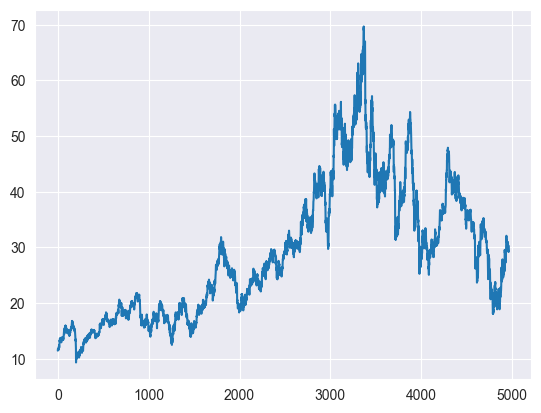

In [7]:
plt.plot(df['GM_AC'])

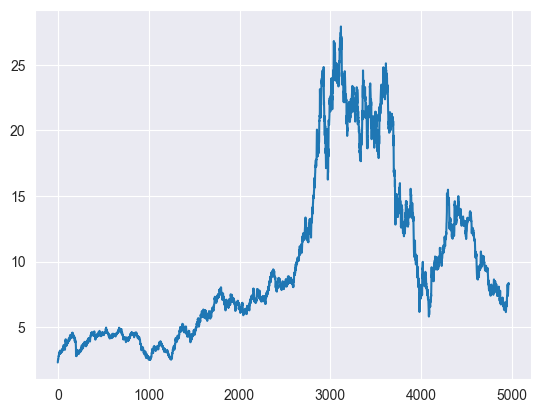

In [11]:
plt.plot(df["F_AC"])
plt.show()

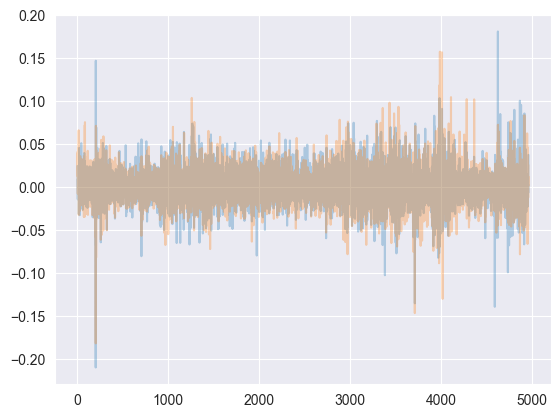

In [14]:
GMReturn = df['GM_AC'] / df['GM_AC'].shift(1) - 1
FReturn = df['F_AC'] / df['F_AC'].shift(1) - 1

plt.plot(GMReturn, alpha=0.3)
plt.plot(FReturn, alpha=0.3)

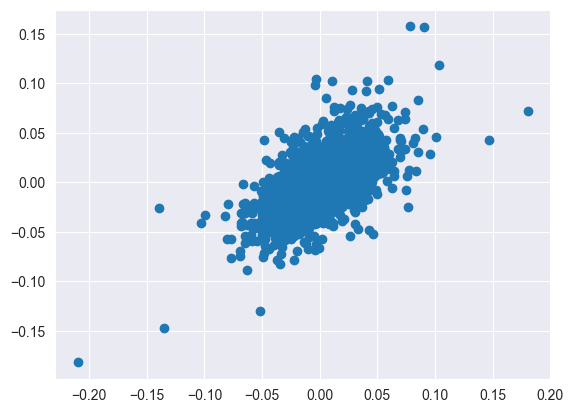

In [17]:
plt.scatter(GMReturn, FReturn)

Yes returns appear positively correlated. Outlying returns seem to occur on similar days.

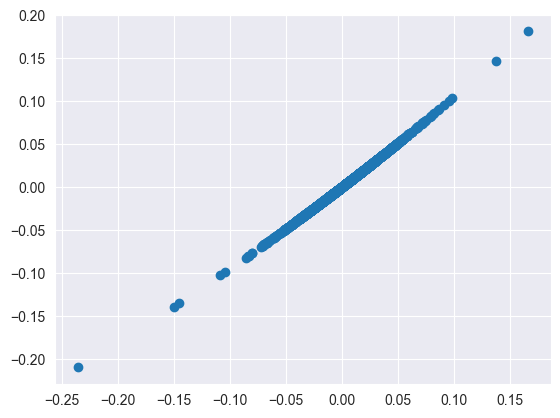

In [19]:
import numpy as np

GMLogreturn = np.log(df['GM_AC']) - np.log(df['GM_AC'].shift(1))

plt.scatter(GMLogreturn, GMReturn)

In [20]:
GMLogreturn.corr(GMReturn)

np.float64(0.9995408292145739)

Yes, log returns highly correlated with standard returns

### Simulations

In [69]:
niter = 10000
res = []

for i in range(niter):
    r = pd.Series(np.random.normal(size=45, loc=0.05/253, scale=0.23/np.sqrt(253)))
    logPrice = np.log(1e6) + r.cumsum()

    sellp = (logPrice > np.log(1100000)).idxmax()
    selll = (logPrice > np.log(1100000)).idxmax()

    if ((sellp > 0) & (selll == 0)) or ((sellp > 0) & (selll > 0) & (sellp < selll)):
        res.append(100000)
    elif ((selll > 0) & (sellp == 0)) or ((selll > 0) & (sellp > 0) & (selll < sellp)):
        res.append(-50000)
    else:
        res.append(np.exp(logPrice.iloc[-1]))


print(f"Simulated Gross Return:", sum(res)/(1e6*niter))

Simulated Gross Return: 1.0132565517426702


### Geometric Random Walk

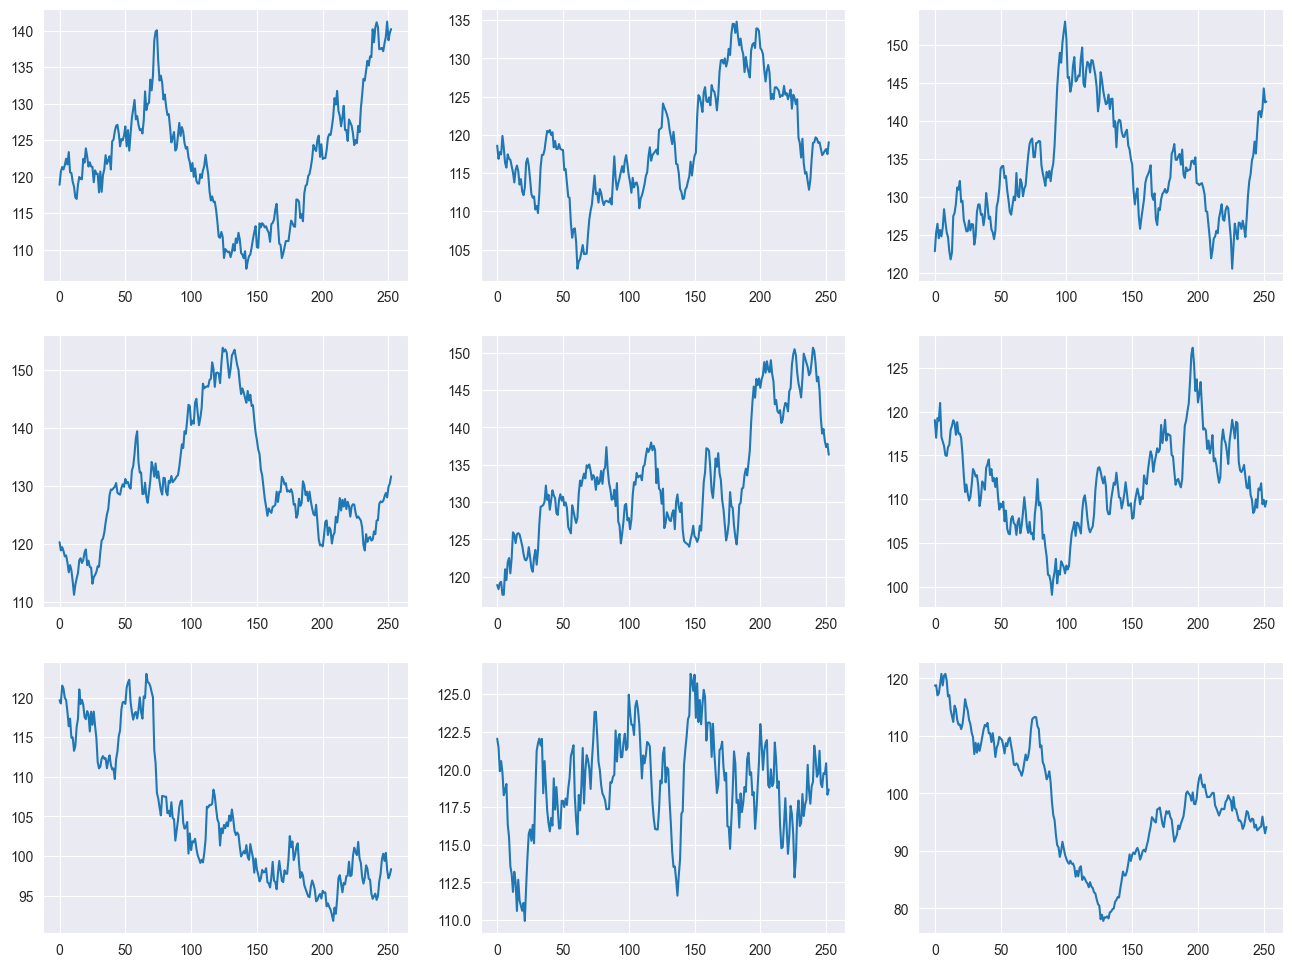

In [72]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
axs = axs.flatten()
n = 253

for i in range(9):
    logr = pd.Series(np.random.normal(size=n, loc=0.05/253, scale=0.2/np.sqrt(253)))
    price = 120 * np.exp(logr.cumsum())
    axs[i].plot(price)

### Mcdonalds

In [74]:
df = pd.read_csv('datasets/MCD_PriceDaily.csv')
df

,Date,Open,High,Low,Close,Volume,Adj Close
0,1/4/2010,62.63,63.07,62.31,62.78,5839300,53.99
1,1/5/2010,62.66,62.75,62.19,62.30,7099000,53.58
2,1/6/2010,62.20,62.41,61.06,61.45,10551300,52.85
3,1/7/2010,61.25,62.34,61.11,61.90,7517700,53.24
4,1/8/2010,62.27,62.41,61.60,61.84,6107300,53.19
...,...,...,...,...,...,...,...
1172,8/29/2014,94.20,94.20,93.51,93.72,4635100,93.72
1173,9/2/2014,93.24,93.70,92.69,92.80,6727100,92.80
1174,9/3/2014,93.27,93.49,93.04,93.14,4855300,93.14
1175,9/4/2014,93.02,93.23,92.80,93.01,4849800,93.01


Corr between log returns and raw returns: 0.9999535551178765


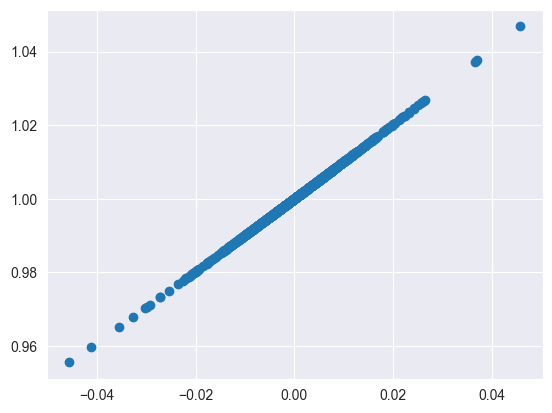

In [83]:
price = df['Adj Close']
returns = price - price.shift(1)
log_returns = np.log(price) - np.log(price).shift(1)
returns2 = price / price.shift(1)

plt.scatter(log_returns, returns2)
print("Corr between log returns and raw returns:", log_returns.corr(returns2))

In [85]:
print(np.exp(log_returns.mean()), log_returns.std())
print(returns2.mean(), returns2.std())

1.0004631625446632 0.008901467457248666
1.0005027479017918 0.00890031928901851


In [87]:
print("Test Statistic", (np.exp(log_returns.mean()) - returns2.mean()/returns2.std()))

Test Statistic -111.411543127639


In [99]:
# simulation
# current price = 93.07, mean = 1.0004631625446632, var = 0.008901467457248666

iter = 10000
res = []

for i in range(iter):
    gbm = pd.Series(np.random.normal(size=20, loc=log_returns.mean(), scale=log_returns.std()))
    price = 93.07 * (np.exp(gbm.cumsum()))
    if price.min() < 85:
        if price.min() < 84.5:
            res.append(110)
        else:
            res.append(85)
    else:
        res.append(-1)


print()
print(sum(res))
print(sum(res)/iter)


730
0.073


In [100]:
np.log(990/1000)

np.float64(-0.01005033585350145)

In [106]:
from scipy.stats import norm

norm.cdf(-0.011/0.15)

np.float64(0.47077043346762865)

In [107]:
norm.cdf(-0.01, loc=0.005, scale=0.015*np.sqrt(5))

np.float64(0.3273604230092886)